## Librerías

In [55]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch
from sklearn.preprocessing import StandardScaler
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

## EDA

In [21]:
# Cargar datos
df = pd.read_csv("sensor_data.csv")

print("Primeras filas:")
print(df.head(20))

print("\nInformación del dataset:")
print(df.info())

print("\nEstadísticas:")
print(df.describe())

Primeras filas:
    temperature  cpu_usage  memory_usage  network_traffic  failure
0     65.960570  51.958185     76.658394       578.454478        0
1     63.348496  77.231336     54.544194       271.224529        0
2     62.903547  12.907835     33.951479       265.656871        0
3     54.863447  38.667050     52.339812        29.056902        0
4     60.810338  23.655540     55.201111       366.638388        0
5     52.796954  75.843676     70.238612       254.666039        0
6     59.838033  31.730360     79.805808       166.873453        0
7     93.339756  81.260074     68.935490       482.264156        1
8     47.890976  20.167527     78.926608       269.278751        0
9     64.123419  16.213117     70.833511       292.237658        0
10    66.985474  74.530466     81.097982       463.249670        0
11    41.902161  79.192233     61.800822       288.442504        0
12    69.750310  84.837281     63.703818       500.529935        0
13    71.675562  72.503100     91.917817      


Distribución de clases:
failure
0    4484
1     516
Name: count, dtype: int64


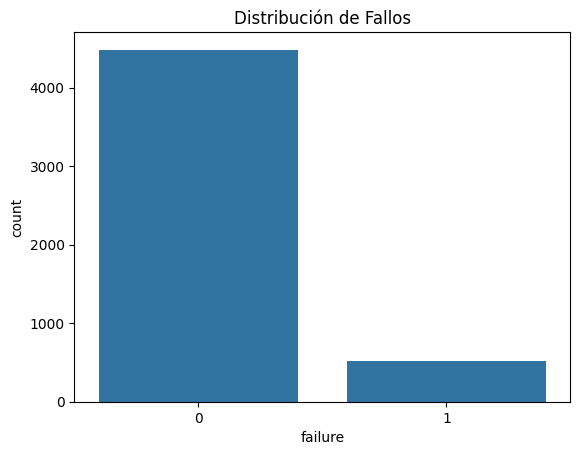

In [22]:
# Distribución de variable objetivo
print("\nDistribución de clases:")
print(df["failure"].value_counts())

sns.countplot(x="failure", data=df)
plt.title("Distribución de Fallos")
plt.show()

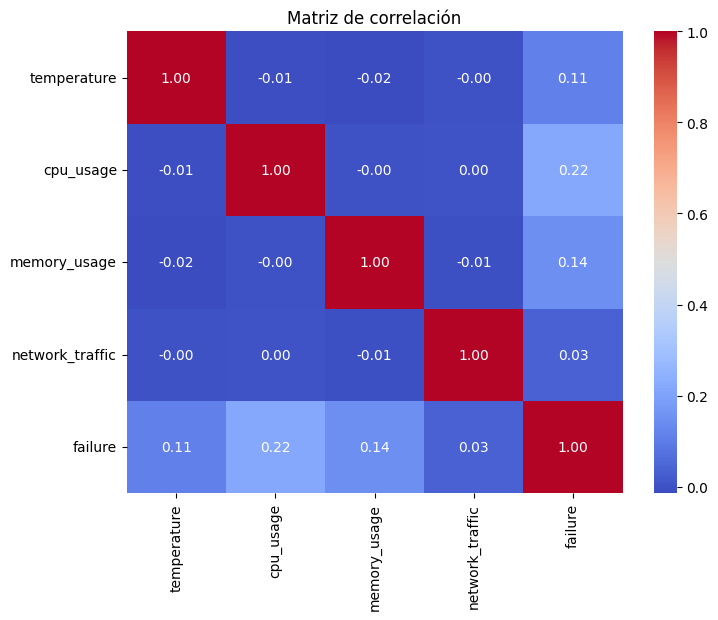

In [23]:
# Correlaciones
plt.figure(figsize=(8,6))
corr = df.corr()

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de correlación")
plt.show()

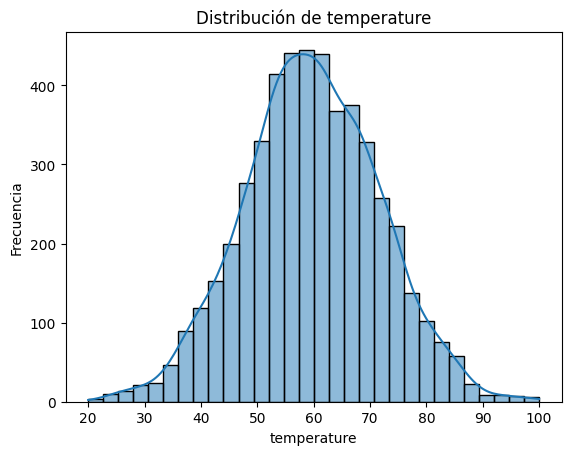

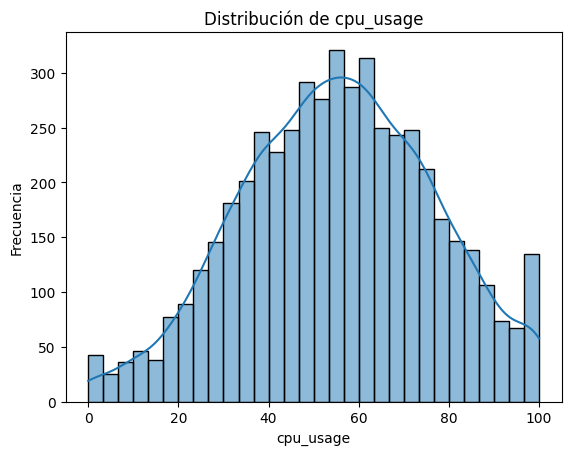

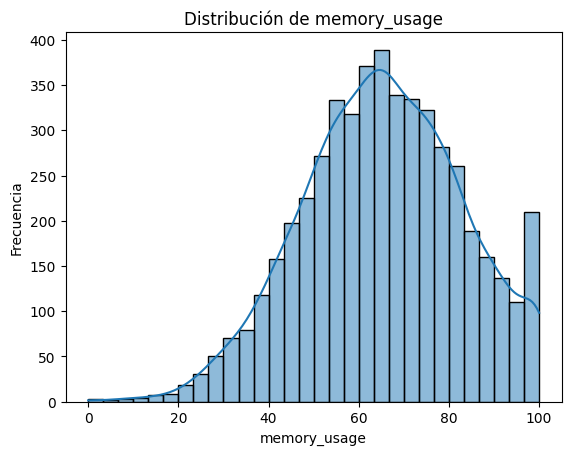

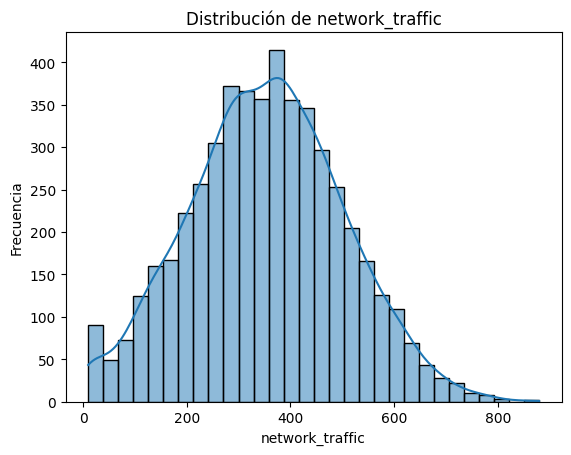

In [24]:
# Distribución de cada variable 
features = ["temperature", "cpu_usage", "memory_usage", "network_traffic"]

for var in features:
    plt.figure()
    sns.histplot(df[var], kde=True, bins=30)
    plt.title(f"Distribución de {var}")
    plt.xlabel(var)
    plt.ylabel("Frecuencia")
    plt.show()

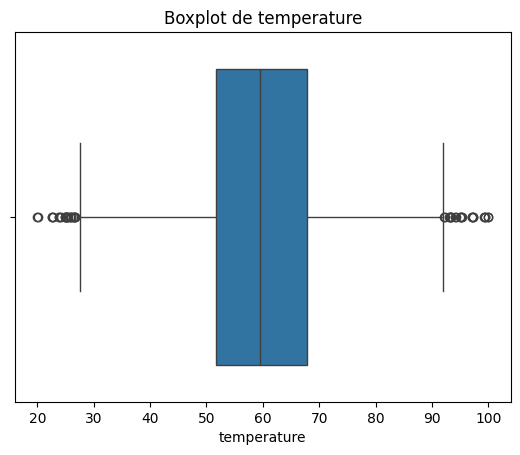

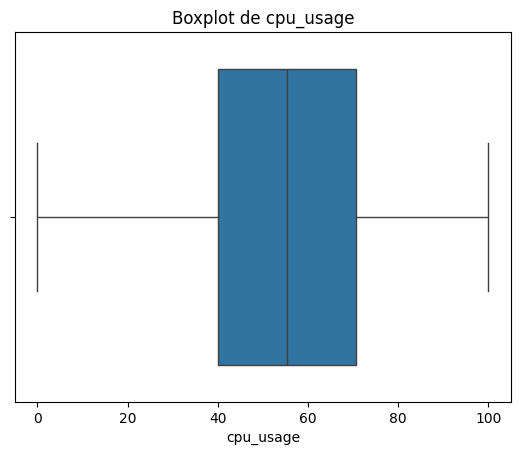

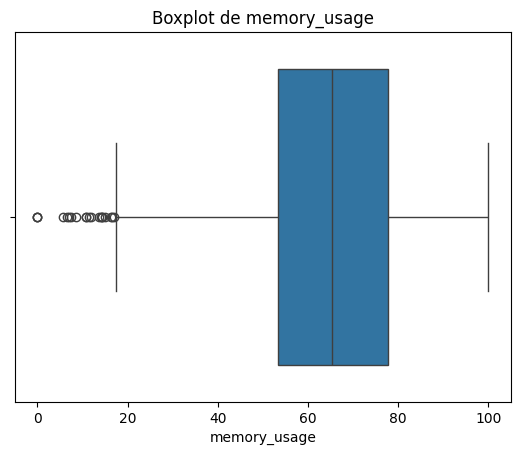

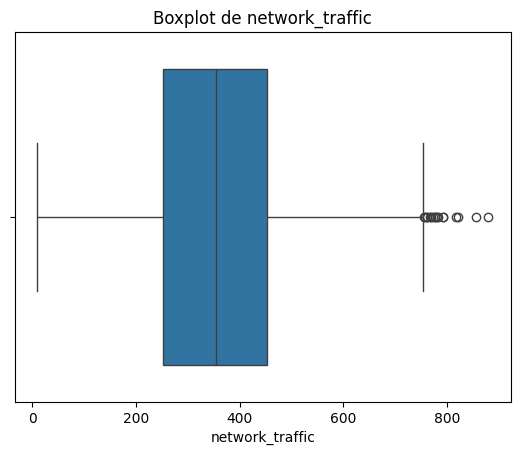

In [25]:
# Boxplots para detección de outliers
for var in features:
    plt.figure()
    sns.boxplot(x=df[var])
    plt.title(f"Boxplot de {var}")
    plt.show()

## Normalización de datos, tensores y split

In [ ]:
# Separar variables X se usara para entrenar el modelo e y es la variable objetivo
X = df.drop("failure", axis=1)
y = df["failure"]

# Normalización de los datos de entrenamiento (desviación estándar 1 y media 0)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\nShape de X:", X_scaled.shape)
print("Shape de y:", y.shape)

X = X_scaled
y = y.values


Shape de X: (5000, 4)
Shape de y: (5000,)


In [ ]:
# Dividir en conjunto de entrenamiento y prueba (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape, X_test.shape)

(4000, 4) (1000, 4)


In [ ]:
# Convertimos las secuencias a tensores de PyTorch
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
y_test = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

## Definición del modelo LSTM

In [ ]:
# Definir el modelo MLP
class MLP(nn.Module):
    def __init__(self, input_size=4):
        super(MLP, self).__init__()

        # Capas del modelo
        self.model = nn.Sequential(
            nn.Linear(input_size, 128), # Capa de entrada a 128 neuronas
            nn.ReLU(), # Función de activación ReLU
            nn.Dropout(0.3), # Capa de dropout para evitar overfitting

            nn.Linear(128, 64), # Capa oculta con 64 neuronas y recibe 128 de la capa anterior
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1) # Capa de salida con 1 neurona para clasificación binaria
        )

    # Método forward
    def forward(self, x):
        return self.model(x)

## Entrenamiento del modelo

In [ ]:
# Crear el modelo, definir la función de pérdida y el optimizador
model = MLP(input_size=4)

neg = (y_train == 0).sum() # Contar el número de ejemplos de la clase negativa (no fallos)
pos = (y_train == 1).sum() # Contar el número de ejemplos de la clase positiva (fallos)

pos_weight = torch.tensor([2.5], dtype=torch.float32) # Ajustar el peso para la clase positiva (fallos) para manejar el desbalance de clases
criterion = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight) # Binary Cross Entropy con pesos para clases desbalanceadas
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [ ]:
epochs = 20 # Número de épocas para entrenamiento

# Entrenamiento del modelo
for epoch in range(epochs):
    model.train()

    optimizer.zero_grad() # Limpiar los gradientes acumulados

    outputs = model(X_train) # Obtener las predicciones del modelo para el conjunto de entrenamiento

    loss = criterion(outputs, y_train) # Calcular la pérdida

    loss.backward() # Propagar el error hacia atrás para calcular los gradientes
    optimizer.step() # Actualizar los pesos del modelo utilizando el optimizador

    # Métricas
    preds = torch.sigmoid(outputs)
    preds_class = (preds > 0.35).float() # Convertir las probabilidades a clases binarias usando un umbral de 0.35

    acc = (preds_class == y_train).float().mean()

    print(f"Epoch {epoch+1}/{epochs} - Loss: {loss.item():.4f} - Acc: {acc.item():.4f}")

Epoch 1/20 - Loss: 0.5867 - Acc: 0.8938
Epoch 2/20 - Loss: 0.5845 - Acc: 0.8955
Epoch 3/20 - Loss: 0.5777 - Acc: 0.8995
Epoch 4/20 - Loss: 0.5705 - Acc: 0.8955
Epoch 5/20 - Loss: 0.5727 - Acc: 0.8953
Epoch 6/20 - Loss: 0.5656 - Acc: 0.8965
Epoch 7/20 - Loss: 0.5618 - Acc: 0.8945
Epoch 8/20 - Loss: 0.5637 - Acc: 0.8882
Epoch 9/20 - Loss: 0.5491 - Acc: 0.8842
Epoch 10/20 - Loss: 0.5456 - Acc: 0.8805
Epoch 11/20 - Loss: 0.5466 - Acc: 0.8705
Epoch 12/20 - Loss: 0.5490 - Acc: 0.8680
Epoch 13/20 - Loss: 0.5460 - Acc: 0.8587
Epoch 14/20 - Loss: 0.5463 - Acc: 0.8470
Epoch 15/20 - Loss: 0.5342 - Acc: 0.8462
Epoch 16/20 - Loss: 0.5363 - Acc: 0.8438
Epoch 17/20 - Loss: 0.5397 - Acc: 0.8340
Epoch 18/20 - Loss: 0.5381 - Acc: 0.8313
Epoch 19/20 - Loss: 0.5374 - Acc: 0.8290
Epoch 20/20 - Loss: 0.5360 - Acc: 0.8255


In [56]:
# Evaluación del modelo en el conjunto de prueba
model.eval()

with torch.no_grad():
    outputs = model(X_test)
    preds = torch.sigmoid(outputs)
    preds_class = (preds > 0.35).float()

print("\nMatriz de Confusión:")
print(confusion_matrix(y_test, preds_class))
print("\nMétricas:")
print(classification_report(y_test, preds_class))


Matriz de Confusión:
[[763 134]
 [ 56  47]]

Métricas:
              precision    recall  f1-score   support

         0.0       0.93      0.85      0.89       897
         1.0       0.26      0.46      0.33       103

    accuracy                           0.81      1000
   macro avg       0.60      0.65      0.61      1000
weighted avg       0.86      0.81      0.83      1000

